In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 41.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
      /tmp/pip-build-env-jajo8o2y/overlay/lib/python3.10/site-packages/setuptools/dist.py:330: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.linux-x86_64-cpython-310/tokenizers
      copying tokenize

In [ ]:
!pip list | grep torch


pytorch-ignite                           0.5.1
pytorch-lightning                        2.4.0
torch                                    2.4.0
torchaudio                               2.4.0
torchinfo                                1.8.0
torchmetrics                             1.4.2
torchvision                              0.19.0


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA Available: True
GPU Name: Tesla T4


In [ ]:
!nvidia-smi


Wed Nov 20 09:08:41 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load the dataset
df = pd.read_csv('/kaggle/input/overall-column-dataset-updated-msc/overall updated upsampled_data.csv')  # Replace with your dataset's file name

# Map scores to labels
def map_scores(score):
    if score in [4, 5]:
        return 2  # Positive
    elif score in [1, 2]:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral

df['Overall_Label'] = df['Overall'].apply(map_scores)  # Replace 'Your_Score_Column' with the actual column name

# Separate the dataset by label
df_0 = df[df['Overall_Label'] == 0]
df_1 = df[df['Overall_Label'] == 1]
df_2 = df[df['Overall_Label'] == 2]

# Perform upsampling
target_size = 3688  # Target size for each label

df_0_upsampled = resample(df_0, replace=True, n_samples=target_size, random_state=42)
df_1_upsampled = resample(df_1, replace=True, n_samples=target_size, random_state=42)
df_2_upsampled = resample(df_2, replace=True, n_samples=target_size, random_state=42)

# Combine the upsampled dataframes
df_balanced = pd.concat([df_0_upsampled, df_1_upsampled, df_2_upsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset to the working directory
df_balanced.to_csv('balanced_dataset.csv', index=False)

print(f"Balanced dataset saved as 'balanced_dataset.csv' in the working directory.")


Balanced dataset saved as 'balanced_dataset.csv' in the working directory.


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
import logging
logging.basicConfig(level=logging.ERROR)



In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/working/balanced_dataset.csv"


df = pd.read_csv(dataset_path)
df.head()


,Combined,Overall,Overall_Label
0,"Name: Md Fazla Rabbi, Job_Title: Senior Softwa...",4,2
1,"Name: Fatima Tasnim, Job_Title: Software Engin...",4,2
2,"Name: Rajesh Debnath, Job_Title: Software Engi...",5,2
3,"Name: Foysol Ahmed Shuvo, Job_Title: Full stac...",3,1
4,"Name: Majbah Uddin, Job_Title: Software Engine...",5,2


In [ ]:
# Create the labels based on score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['Overall_Label'] = df['Overall'].apply(map_labels)

print("Mapped Overall_Label:")
print(df['Overall_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/Overall_Label.csv', index=False)


Mapped Overall_Label:
Overall_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  Overall  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...        4              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...        4              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...        5              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...        3              1
4  Name: Majbah Uddin, Job_Title: Software Engine...        5              2


In [ ]:

from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

tokenizer = RobertaTokenizer.from_pretrained('distilroberta-base')


df = pd.read_csv("/kaggle/working/Overall_Label.csv")

def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'Overall_Label']].head())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...              1
4  Name: Majbah Uddin, Job_Title: Software Engine...              2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/Overall_Label.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Check the shape of the split data
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Overall_Label']


        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create DataLoader objects to handle batching
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break


Input IDs: tensor([[    0, 31723,    35,  ...,     9,  3288,     2],
        [    0, 31723,    35,  ..., 11143, 24379,     2],
        [    0, 31723,    35,  ...,   994,   196,     2],
        ...,
        [    0, 31723,    35,  ...,   336,   111,     2],
        [    0, 31723,    35,  ..., 50118, 46608,     2],
        [    0, 31723,    35,  ..., 39750, 50118,     2]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 2, 1, 1, 1])


In [ ]:
from transformers import DistilBertForSequenceClassification, AdamW
import torch
import torch.nn as nn
from torch.optim import AdamW

# Define the DistilRoBERTa-based model
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()

        self.distilroberta = DistilBertForSequenceClassification.from_pretrained('distilroberta-base', num_labels=num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through DistilRoBERTa
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        return output.logits

# Initialize the model
model = DistilRobertaClass(num_labels=3)  # I have 3 labels: Negative (0), Neutral (1), Positive (2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the loss function
criterion = nn.CrossEntropyLoss()

# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)  # A typical learning rate for fine-tuning DistilRoBERTa
print(model)


You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k_lin.weight', 'transformer.layer.0.attention.out_lin.bias', 'transformer.layer.0.attention.out_lin.weight', 'transformer.layer.0.attention.q_lin.bias', 'transformer.layer.0.attention.q_lin.weight', 'transformer.layer.0.attention.v_lin.bias', 'transformer.layer.0.attention.v_lin.weight', 'transformer.layer.0.ffn.lin1.bias', 'transformer.layer.0.ffn.lin1.weight', 'transformer.layer.0.ffn.lin2.bias', 'transformer.layer.0.ffn.lin2.weight', 'transformer.layer.0.output_layer_norm.bias', 'transformer.layer.0.output_layer_norm.weight', 'transformer.la

DistilRobertaClass(
  (distilroberta): DistilBertForSequenceClassification(
    (distilbert): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): MultiHeadSelfAttention(
              (dropout): Dropout(p=0.1, inplace=False)
              (q_lin): Linear(in_features=768, out_features=768, bias=True)
              (k_lin): Linear(in_features=768, out_features=768, bias=True)
              (v_lin): Linear(in_features=768, out_features=768, bias=True)
              (out_lin): Linear(in_features=768, out_features=768, bias=True)
            )
            (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
 

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import RobertaTokenizerFast, DistilBertForSequenceClassification, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split

# Define the custom Dataset class to handle the text and labels
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



texts = df['Combined'].tolist()
labels = df['Overall_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)
tokenizer = RobertaTokenizerFast.from_pretrained('distilroberta-base')

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Create dataloaders for batching
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the DistilRoBERTa model class
class DistilRobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(DistilRobertaClass, self).__init__()

        self.distilroberta = DistilBertForSequenceClassification.from_pretrained(
            'distilroberta-base', num_labels=num_labels,
            output_attentions=False, output_hidden_states=False
        )
        # Dropout layer
        self.distilroberta.config.attention_probs_dropout_prob = 0.2

    def forward(self, input_ids, attention_mask):
        output = self.distilroberta(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits


model = DistilRobertaClass(num_labels=3)  # 3 classes (Negative, Neutral, Positive)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up optimizer
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training and evaluation loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=10):
    best_val_loss = float('inf')
    patience = 2  # Early stopping patience
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        # Evaluate on validation set
        model.eval()
        correct_val = 0
        total_val = 0
        running_val_loss = 0.0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs  # Logits are returned directly

                loss = criterion(logits, labels)
                running_val_loss += loss.item()

                # Calculate validation accuracy
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0  # Reset counter
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=18)


/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You are using a model of type roberta to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'transformer.layer.0.attention.k_lin.bias', 'transformer.layer.0.attention.k

Epoch 1/18
Training Loss: 1.1022, Training Accuracy: 0.3334
Validation Loss: 1.0887, Validation Accuracy: 0.4157
Epoch 2/18
Training Loss: 1.0910, Training Accuracy: 0.3792
Validation Loss: 1.0769, Validation Accuracy: 0.6643
Epoch 3/18
Training Loss: 1.0801, Training Accuracy: 0.4168
Validation Loss: 1.0642, Validation Accuracy: 0.4939
Epoch 4/18
Training Loss: 1.0700, Training Accuracy: 0.4497
Validation Loss: 1.0481, Validation Accuracy: 0.6475
Epoch 5/18
Training Loss: 1.0562, Training Accuracy: 0.4882
Validation Loss: 1.0288, Validation Accuracy: 0.7257
Epoch 6/18
Training Loss: 1.0372, Training Accuracy: 0.5408
Validation Loss: 1.0038, Validation Accuracy: 0.7795
Epoch 7/18
Training Loss: 1.0150, Training Accuracy: 0.5816
Validation Loss: 0.9725, Validation Accuracy: 0.7497
Epoch 8/18
Training Loss: 0.9836, Training Accuracy: 0.6272
Validation Loss: 0.9316, Validation Accuracy: 0.7438
Epoch 9/18
Training Loss: 0.9468, Training Accuracy: 0.6589
Validation Loss: 0.8794, Validation 

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='distilroberta_model.pth', tokenizer_path='distilroberta_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to distilroberta_model.pth
Tokenizer saved to distilroberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       735
     Class 1       0.84      0.89      0.87       752
     Class 2       0.88      0.83      0.85       726

    accuracy                           0.91      2213
   macro avg       0.91      0.91      0.91      2213
weighted avg       0.91      0.91      0.91      2213

Hamming Loss: 0.0944


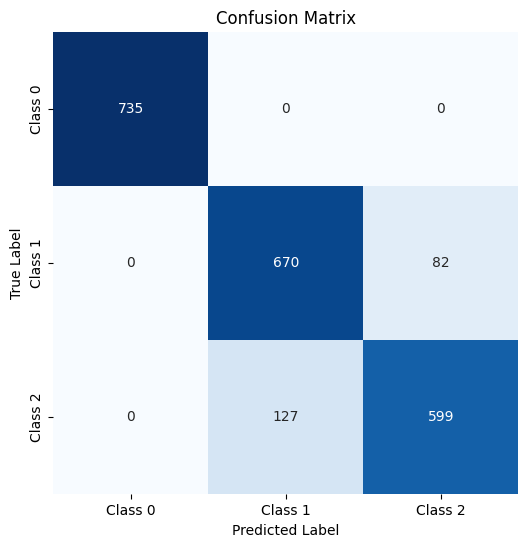

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Class 0","Class 1", "Class 2"], yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


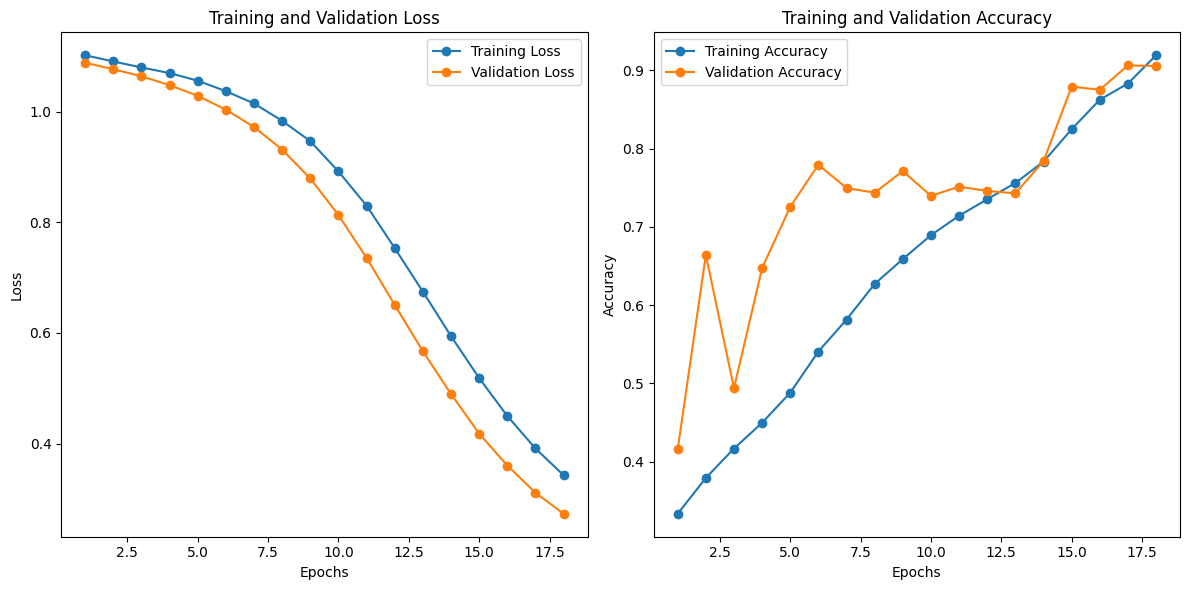

In [ ]:
import matplotlib.pyplot as plt

# Data from the training log
epochs = list(range(1, 19))
training_loss = [
    1.1022, 1.0910, 1.0801, 1.0700, 1.0562, 1.0372, 1.0150, 0.9836, 0.9468,
    0.8920, 0.8302, 0.7534, 0.6747, 0.5943, 0.5184, 0.4499, 0.3911, 0.3428
]
validation_loss = [
    1.0887, 1.0769, 1.0642, 1.0481, 1.0288, 1.0038, 0.9725, 0.9316, 0.8794,
    0.8132, 0.7358, 0.6507, 0.5670, 0.4896, 0.4181, 0.3603, 0.3111, 0.2730
]
training_accuracy = [
    0.3334, 0.3792, 0.4168, 0.4497, 0.4882, 0.5408, 0.5816, 0.6272, 0.6589,
    0.6895, 0.7143, 0.7354, 0.7562, 0.7834, 0.8249, 0.8626, 0.8833, 0.9194
]
validation_accuracy = [
    0.4157, 0.6643, 0.4939, 0.6475, 0.7257, 0.7795, 0.7497, 0.7438, 0.7714,
    0.7397, 0.7515, 0.7460, 0.7429, 0.7840, 0.8793, 0.8753, 0.9065, 0.9056
]

# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, label="Training Loss", marker='o')
plt.plot(epochs, validation_loss, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, training_accuracy, label="Training Accuracy", marker='o')
plt.plot(epochs, validation_accuracy, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()
